# 14_04 — Evaluación predictiva · Escenario 4

Paso **3b** del ciclo. Supone que `14_03_convergencia` dio veredicto ✓; si las
cadenas no convergieron, nada de lo que sigue significa algo.


## Qué se reporta

| Sección | Qué responde |
|---|---|
| 4 | métricas puntuales y distribucionales, **train vs test** |
| 5 | bandas de credibilidad sobre la serie de cada score |
| 6 | intervalos sobre la curva, en extractos cada 10 períodos |
| 7 | ventana móvil: cómo evoluciona el error al cruzar $T_0$ |
| 8 | calibración marginal: PIT por bloque |
| **9** | **¿recupera la predictiva la asimetría de la condicional?** |
| 10 | comparación con las líneas base, y el contraste con la corrida 11 |

Todo el cálculo vive en `fit/` y todo el dibujo en `graphics/`: este notebook
sólo orquesta.

## 1. Imports, rutas y artefactos

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.stats import norm as _norm

from model_psbp_fd.pipelines import (
    cargar_curvas, cargar_curvas_true, cargar_fpca, cargar_estandarizador,
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
    cargar_escenario,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.models.pspb_fd_v3 import PSBPPredictor, PropagadorFuncional

from model_psbp_fd.fit import (
    # puntual
    rmse_por_coeficiente, r2_por_columna, razon_dispersion, mise, rmse_funcional,
    # distribucional muestral
    crps_muestral, energy_score, cobertura, intervalo_muestral,
    pit_muestral, diagnostico_pit,
    # agrupación de cadenas y ventana móvil
    agrupar_momentos, ventana_movil_scores, ventana_movil_funcional,
)
from model_psbp_fd.graphics import (
    plot_ventana_movil, plot_bandas_serie, plot_extractos_curvas,
    plot_calibracion_pit, plot_scatter_theta,
)
from model_psbp_fd.utils import get_project_root

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [2]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG] debe coincidir con 14_01, 14_03 y psbp_fd_iteracion.m
BASENAME, ESCENARIO_ID, REPLICA_ID = "escenario", 4, 1
EXPERIMENT_ID = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}"

PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / EXPERIMENT_ID,
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / EXPERIMENT_ID,
    "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / EXPERIMENT_ID,
    "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / EXPERIMENT_ID,
}
for r in PATHS.values():
    r.mkdir(parents=True, exist_ok=True)
print(f"EXPERIMENT_ID : {EXPERIMENT_ID}")

EXPERIMENT_ID : escenario_4_r01


In [3]:
dfs_train, manifest = cargar_datasets_ar(PATHS, bloque="train")
dfs_test,  _        = cargar_datasets_ar(PATHS, bloque="test")
hp_json     = cargar_hiperparametros(PATHS)
eval_config = cargar_config_evaluacion(PATHS)

COMPONENT_IDX = manifest["component_idx"]
n_components  = len(COMPONENT_IDX)
cov_names     = manifest["cov_names"]
N_LAGS        = int(manifest["n_lags"])
T, T0         = int(manifest["T"]), int(manifest["T0"])
N_ITER        = int(hp_json["n_iter"])
MCMC_CFG      = hp_json["mcmc_config"]
BURN          = int(MCMC_CFG["burn"])

assert manifest["scores_scale"] == "standardized_zscore_ddof0"

# Parámetros de evaluación: se LEEN del artefacto, no se redeclaran aquí.
NIVEL        = float(eval_config.get("nivel_credibilidad", 0.95))
MODO_RESIDUO = eval_config.get("modo_residuo", "ninguno")
OBJETIVO     = eval_config.get("objetivo_evaluacion", "curva_verdadera")
VENTANAS_W   = list(eval_config.get("ventana_movil", {}).get("w", [10, 20, 40]))
FORMA_CFG    = eval_config.get("forma_predictiva", {})
REF_CFG      = eval_config.get("comparacion_de_referencia", {})

# La ausencia de estratificación es una declaración, no un descuido.
assert eval_config.get("estratificacion") is None, (
    "Este notebook está escrito para un escenario SIN estado latente. "
    "eval_config declara una estratificación: revisar 14_01 o usar la "
    "plantilla de la corrida 13.")

print(f"T={T}  T0={T0}  n_lags={N_LAGS}  componentes={n_components}")
print(f"nivel={NIVEL}  ·  modo_residuo={MODO_RESIDUO!r}  ·  objetivo={OBJETIVO!r}")
print(f"ventanas w = {VENTANAS_W}")
print(f"\nestratificación: NINGUNA. Motivo declarado en el artefacto:")
print("  " + eval_config.get("estratificacion_motivo", "(no declarado)"))
print(f"\nreferencia del generador para §9:")
for _k, _v in FORMA_CFG.items():
    print(f"  {_k:26s}: {_v}")

T=400  T0=280  n_lags=1  componentes=3
nivel=0.95  ·  modo_residuo='ninguno'  ·  objetivo='curva_verdadera'
ventanas w = [10, 20, 40]

estratificación: NINGUNA. Motivo declarado en el artefacto:
  El Algoritmo 4 no tiene estado latente: la asimetría es una propiedad constante de la ley de la innovación, no un régimen ni un nivel de volatilidad que cambie de origen a origen. Estratificar por cuantiles de una cantidad observada inventaría un eje que el generador no tiene. 14_04 omite la sección de calibración condicional, como la corrida 11.

referencia del generador para §9:
  familia                   : st
  delta_skew                : 0.85
  nu                        : 5.0
  asimetria_innovacion      : 1.72559654996661
  curtosis_innovacion       : 15.876138054595582
  asimetria_curvas          : 0.5724468602603612
  curtosis_curvas           : 3.730190958354001
  asimetria_scores_train    : [-0.7399887983013824, -0.6129604026719377, 0.10074934267202858]
  curtosis_scores_train     : 

In [4]:
fpca = cargar_fpca(PATHS)
_ver = fpca.verificar()
assert _ver["todo_ok"], f"Las identidades FPCA no se cumplen: {_ver}"

scores_standardizer = cargar_estandarizador(PATHS, DataStandardizer)
X_obs, grilla = cargar_curvas(PATHS)                 # (T, G) con ruido
X_true        = cargar_curvas_true(PATHS)            # (T, G) verdadera — el objetivo

M_fpca   = fpca.M
Psi_grid, mu_grid = fpca.Psi_grid, fpca.mu_grid
SCORES     = fpca.SCORES                              # (T, M) escala original
SCORES_STD = scores_standardizer.transform(SCORES)

print(f"FPCA M={M_fpca} K={fpca.K}   ·   curvas {X_true.shape}  grilla {grilla.shape}")
print(f"sd(observada - verdadera) = {(X_obs - X_true).std():.4f}   "
      "← el ruido que el modelo NO debe predecir")
assert COMPONENT_IDX == list(range(M_fpca)), (
    "La propagación funcional necesita el vector completo de scores en orden; "
    f"COMPONENT_IDX={COMPONENT_IDX} y M={M_fpca}.")

FPCA M=3 K=8   ·   curvas (400, 75)  grilla (75,)
sd(observada - verdadera) = 0.2505   ← el ruido que el modelo NO debe predecir


### 1.1 Momentos verdaderos del generador

En lugar del estado latente que leen las corridas 12 y 13, aquí se leen los
**momentos** que el generador produjo: la asimetría y la curtosis de la curva y
del residuo autorregresivo, punto a punto del dominio. `14_01` los calculó y
persistió en `10_momentos_curva.csv`; si faltara, las cifras de referencia están
igualmente en el bloque `forma_predictiva` de `eval_config.json`.

Ninguna de estas cantidades entra en predicción alguna: son el patrón contra el
cual §9 contrasta la forma de la predictiva.

In [5]:
_csv_mom = PATHS["out_report"] / "10_momentos_curva.csv"
if _csv_mom.exists():
    momentos_df = pd.read_csv(_csv_mom)
    asim_curva_true   = float(np.nanmean(momentos_df["asimetria_curva"]))
    curt_curva_true   = float(np.nanmean(momentos_df["curtosis_curva"]))
    asim_residuo_true = float(np.nanmean(momentos_df["asimetria_residuo"]))
    curt_residuo_true = float(np.nanmean(momentos_df["curtosis_residuo"]))
    _fuente = _csv_mom.name
else:
    asim_curva_true   = float(FORMA_CFG.get("asimetria_curvas", np.nan))
    curt_curva_true   = float(FORMA_CFG.get("curtosis_curvas", np.nan))
    asim_residuo_true = float(FORMA_CFG.get("asimetria_innovacion", np.nan))
    curt_residuo_true = float(FORMA_CFG.get("curtosis_innovacion", np.nan))
    _fuente = "eval_config.json::forma_predictiva"
    print("[AVISO] Sin 10_momentos_curva.csv; se usan las cifras del artefacto.")

# Asimetría de los scores en el bloque de ENTRENAMIENTO tal como la registró
# 14_01. Es la referencia por componente contra la que §9 compara.
ASIM_SCORES_TRUE = np.asarray(FORMA_CFG.get("asimetria_scores_train", []), float)

print(f"momentos verdaderos leídos de {_fuente}")
print(f"  asimetría de la curva      : {asim_curva_true:+.4f}")
print(f"  curtosis  de la curva      : {curt_curva_true:.4f}   (gaussiana = 3)")
print(f"  asimetría del residuo AR   : {asim_residuo_true:+.4f}")
print(f"  curtosis  del residuo AR   : {curt_residuo_true:.4f}")
print(f"  asimetría de los scores    : "
      f"{np.array2string(ASIM_SCORES_TRUE, precision=3)}")

momentos verdaderos leídos de 10_momentos_curva.csv
  asimetría de la curva      : +0.5724
  curtosis  de la curva      : 3.7302   (gaussiana = 3)
  asimetría del residuo AR   : +0.9014
  curtosis  del residuo AR   : 5.2481
  asimetría de los scores    : [-0.74  -0.613  0.101]


## 2. Trazas MCMC

In [6]:
def ruta_traza(fpc_idx, chain):
    return PATHS["out_artefact"] / f"chain_fpc_{fpc_idx}_iter{chain:02d}.mat"


def leer_traza(path):
    m = loadmat(str(path))
    claves = ["betajhout", "beta0hout", "tauhout", "alphahout", "psijhout",
              "Gammajhout", "gammajhout", "pijout", "wjout", "osumout", "inEout"]
    traces = {k: np.asarray(m[k], dtype=np.float64) for k in claves}
    burn = int(np.asarray(m["burn"]).ravel()[0])
    feat = str(np.atleast_1d(m["feature_names"]).ravel()[0]).split(",")
    return traces, burn, feat


class ModeloTraza:
    def __init__(self, traces, burn, feature_names):
        self.traces = traces
        self.feature_names_ = list(feature_names)
        self.burn = int(burn)
        self.predictor_ = PSBPPredictor(traces=traces, burn=burn)

    def _diseno(self, df):
        Xp = np.asarray(df.iloc[:, 1:], dtype=float)
        return np.hstack([np.ones((Xp.shape[0], 1)), Xp])

    def momentos(self, df):
        return self.predictor_.momentos_predictivos(self._diseno(df))

    def muestrear(self, df, d=1, seed=None):
        return self.predictor_.muestrear(self._diseno(df), d, seed=seed)


faltan = [ruta_traza(COMPONENT_IDX[k] + 1, c + 1).name
          for k in range(n_components) for c in range(N_ITER)
          if not ruta_traza(COMPONENT_IDX[k] + 1, c + 1).exists()]
assert not faltan, f"Faltan trazas: {faltan}. Ejecuta psbp_fd_iteracion.m."

models_chains = {k: {} for k in range(n_components)}
for k in range(n_components):
    esperado = list(dfs_train[k].columns[1:])
    for c in range(N_ITER):
        traces, burn, feat = leer_traza(ruta_traza(COMPONENT_IDX[k] + 1, c + 1))
        assert feat == esperado, f"[k={k} c={c+1}] feature_names != columnas del dataset."
        models_chains[k][c] = ModeloTraza(traces, burn, feat)

n_post = MCMC_CFG["nsim"] - BURN
print(f"OK  {n_components} x {N_ITER} cadenas · {n_post} draws posteriores c/u")

OK  3 x 3 cadenas · 1500 draws posteriores c/u


## 3. Predicción a $h=1$ sobre la serie completa

Los dos bloques se concatenan en **una sola serie de orígenes**
$t=N_{lags}+1,\dots,T$. Ésa es la diferencia con el flujo anterior, que sólo
evaluaba el bloque de prueba: sin el tramo de entrenamiento no hay con qué
comparar el salto en $T_0$, que es la lectura principal de la ventana móvil.

En todos los orígenes la predicción usa los **rezagos reales** —nunca
predicciones encadenadas—, de modo que el horizonte es 1 en todo el recorrido y
el modelo no se reentrena en ningún punto.

In [7]:
# Número de extracciones de la predictiva por draw posterior. El total es
#     S = (nsim - burn) × S_POR_ITER × n_cadenas
# y d=1 ya da varios miles: subirlo sólo reduce el error Monte Carlo de estimar
# los cuantiles, no cambia la predictiva.
#
# [FIX memoria] estaba en 100, que con estos tamaños pedía varios GB para
# `SC_draws` en float64. Con 10 el total son decenas de miles de extracciones,
# error MC del cuantil al 2.5% del orden de 0.002 sd, y el cubo cabe holgado.
S_POR_ITER = 10
SEED_PRED  = 20260823

dfs_full = {k: pd.concat([dfs_train[k], dfs_test[k]], ignore_index=True)
            for k in range(n_components)}
n_orig   = len(dfs_full[0])
t_orig   = np.arange(N_LAGS + 1, T + 1)          # tiempo del experimento, base-1
assert len(t_orig) == n_orig, f"{len(t_orig)} != {n_orig}"

T0_orig  = T0 - N_LAGS
es_train = t_orig <= T0

print(f"orígenes evaluados: {n_orig}  (train {es_train.sum()} · test {(~es_train).sum()})")

_mem_gb = n_post * S_POR_ITER * N_ITER * n_orig * n_components * 4 / 1e9
print(f"SC_draws reservará {_mem_gb * 1e3:.0f} MB en float32")
assert _mem_gb < 2.0, (
    f"SC_draws pediría {_mem_gb:.1f} GB. Baja S_POR_ITER antes de continuar.")

orígenes evaluados: 399  (train 279 · test 120)
SC_draws reservará 215 MB en float32


In [8]:
# Momentos y extracciones por score, agrupando cadenas.
#   momentos : ley de varianza total entre cadenas (fit.agrupar_momentos)
#   muestras : concatenación, que es la mezcla de igual peso
#
# [FIX memoria] `SC_draws` se PREASIGNA y cada cadena se escribe en su rebanada.
# El patrón anterior (lista → np.concatenate → np.stack) mantenía vivas tres
# copias del cubo a la vez. float32 basta: estos draws sólo alimentan cuantiles,
# CRPS, PIT y la ventana móvil. La propagación funcional recasta a float64.
Y_obs  = np.column_stack([dfs_full[k].iloc[:, 0].to_numpy() for k in range(n_components)])
Y_hat  = np.empty_like(Y_obs)
Y_sd   = np.empty_like(Y_obs)

S_POR_CADENA = n_post * S_POR_ITER
S_total      = S_POR_CADENA * N_ITER
SC_draws     = np.empty((S_total, n_orig, n_components), dtype=np.float32)

for k in range(n_components):
    medias, sds = [], []
    for j, c in enumerate(sorted(models_chains[k])):
        mom = models_chains[k][c].momentos(dfs_full[k])
        medias.append(mom["media"])
        sds.append(mom["sd"])            # PREDICTIVA (v3), no la del centro
        muestras_c = models_chains[k][c].muestrear(
            dfs_full[k], S_POR_ITER, seed=SEED_PRED + 1000 * k + c)
        assert muestras_c.shape == (S_POR_CADENA, n_orig), (
            f"[k={k} c={c}] muestrear devolvió {muestras_c.shape}; se esperaba "
            f"({S_POR_CADENA}, {n_orig}). ¿nsim/burn del .mat difieren del JSON?")
        SC_draws[j * S_POR_CADENA:(j + 1) * S_POR_CADENA, :, k] = muestras_c
        del muestras_c
    Y_hat[:, k], Y_sd[:, k] = agrupar_momentos(np.column_stack(medias),
                                               np.column_stack(sds))

li_s, ls_s = intervalo_muestral(SC_draws, nivel=NIVEL)   # (n_orig, M)

print(f"extracciones por score: S = {S_total} "
      f"= {n_post} draws × {S_POR_ITER} × {N_ITER} cadenas")
print(f"SC_draws {SC_draws.shape} {SC_draws.dtype} "
      f"({SC_draws.nbytes / 1e6:.0f} MB)  ·  bandas {li_s.shape}")

extracciones por score: S = 45000 = 1500 draws × 10 × 3 cadenas
SC_draws (45000, 399, 3) float32 (215 MB)  ·  bandas (399, 3)


### 3.1 Propagación a la curva

$\hat X^{(s)}_t(\tau)=\mu(\tau)+\sum_m (d_m\tilde\xi^{(s)}_{tm}+c_m)\psi_m(\tau)$,
que es (3.41) del documento. Con `modo_residuo="ninguno"` el mapa es
determinista y las curvas son extracciones exactas de la predictiva de la curva
**proyectada**.

Las muestras funcionales se **adelgazan** antes de propagar: el arreglo completo
sería $(S, n, G)$ y con $S$ de varios miles ocupa más de un gigabyte sin que los
cuantiles al 95 % mejoren de forma apreciable.

In [9]:
S_FUNC = 500
paso_thin = max(1, S_total // S_FUNC)
SC_thin = SC_draws[::paso_thin]

propagador = PropagadorFuncional(Psi_grid, mu_grid,
                                 estandarizador=scores_standardizer,
                                 modo_residuo=MODO_RESIDUO)
X_draws = propagador.curvas_desde_scores(SC_thin, seed=SEED_PRED)   # (S', n, G)
X_pred  = X_draws.mean(axis=0)                                       # (n, G)
li_f, ls_f = np.quantile(X_draws, (1 - NIVEL) / 2, axis=0), \
             np.quantile(X_draws, 1 - (1 - NIVEL) / 2, axis=0)

X_true_ev = X_true[N_LAGS:]     # (n_orig, G) VERDADERA — contra esto se evalúa
X_obs_ev  = X_obs[N_LAGS:]      # (n_orig, G) observada, sólo para las figuras

print(f"muestras funcionales {X_draws.shape}  (adelgazado 1 de cada {paso_thin})")
print(f"memoria aprox {X_draws.nbytes / 1e6:.0f} MB")

X_proj = fpca.reconstruct(SCORES)[N_LAGS:]
print(f"\nMISE del TRUNCAMIENTO (proyección FPCA de la curva verdadera): "
      f"{mise(X_true_ev, X_proj, grilla):.6f}")
print("   ← ningún modelo sobre esta representación puede bajar de ahí")

muestras funcionales (500, 399, 75)  (adelgazado 1 de cada 90)
memoria aprox 120 MB

MISE del TRUNCAMIENTO (proyección FPCA de la curva verdadera): 0.041886
   ← ningún modelo sobre esta representación puede bajar de ahí


## 4. Métricas, entrenamiento contra prueba

La comparación train/test es la que separa el ajuste de la generalización.
En el Escenario 4 —dinámica idéntica a la del Algoritmo 1, sólo cambia la ley
de la innovación— **las dos columnas deberían parecerse**: si el test se
degrada mucho hay sobreajuste, y la referencia contra la cual leerlo es la
corrida 11.

In [10]:
def _metricas_bloque(mask, etiqueta):
    """Métricas puntuales y distribucionales sobre un subconjunto de orígenes."""
    filas = []
    for k in range(n_components):
        y, p = Y_obs[mask, k], Y_hat[mask, k]
        z    = SC_draws[:, mask, k]
        cob  = cobertura(y, li_s[mask, k], ls_s[mask, k])
        pit  = pit_muestral(y, z)
        filas.append({
            "bloque":  etiqueta,
            "FPC":     f"FPC {COMPONENT_IDX[k] + 1}",
            "RMSE":    float(rmse_por_coeficiente(y[:, None], p[:, None])[0]),
            "R2":      float(r2_por_columna(y[:, None], p[:, None], centrar=True)[0]),
            "sd_ratio": float(razon_dispersion(y[:, None], p[:, None])[0]),
            "CRPS":    float(crps_muestral(y, z).mean()),
            f"Cob{int(NIVEL*100)}": cob["cobertura"],
            "Ancho":   cob["ancho_medio"],
            "PIT_ks":  float(diagnostico_pit(pit)["ks"]),
            "PIT_forma": diagnostico_pit(pit)["forma"],
            "n":       int(mask.sum()),
        })
    return filas

met_df = pd.DataFrame(_metricas_bloque(es_train, "train")
                      + _metricas_bloque(~es_train, "test"))
met_df = met_df.set_index(["bloque", "FPC"])
met_df.to_csv(PATHS["out_report"] / "50_metricas_scores.csv")

_num = [c for c in met_df.columns if met_df[c].dtype.kind == "f"]
display(met_df.style
    .format({c: "{:.4f}" for c in _num})
    .background_gradient(subset=["RMSE", "CRPS"], cmap="RdYlGn_r")
    .background_gradient(subset=["R2"], cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=[f"Cob{int(NIVEL*100)}"], cmap="RdYlGn",
                         vmin=0.80, vmax=1.0)
    .set_caption("Métricas por score y bloque · CRPS y cobertura desde la "
                 "predictiva MUESTRAL"))

_deg = (met_df.loc["test", "RMSE"].mean() / met_df.loc["train", "RMSE"].mean())
print(f"\nRMSE test / RMSE train = {_deg:.3f}"
      + ("   sin degradación apreciable" if _deg < 1.15
         else "   ← el modelo se degrada fuera de muestra"))
print(f"R2 medio (test) = {met_df.loc['test', 'R2'].mean():+.4f}")
print("   Debe parecerse al de la corrida 11: la media condicional es la MISMA. "
      "Un R2\n   apreciablemente distinto indicaría que algo más cambió entre "
      "las dos corridas.")


RMSE test / RMSE train = 1.021   sin degradación apreciable
R2 medio (test) = +0.1276
   Debe parecerse al de la corrida 11: la media condicional es la MISMA. Un R2
   apreciablemente distinto indicaría que algo más cambió entre las dos corridas.


In [11]:
# Métricas funcionales, contra la curva VERDADERA
filas_f = []
for mask, etq in ((es_train, "train"), (~es_train, "test")):
    dentro = (X_true_ev[mask] >= li_f[mask]) & (X_true_ev[mask] <= ls_f[mask])
    filas_f.append({
        "bloque": etq,
        "MISE":   mise(X_true_ev[mask], X_pred[mask], grilla),
        "RMSE_f": rmse_funcional(X_true_ev[mask], X_pred[mask], grilla),
        "MISE_truncamiento": mise(X_true_ev[mask], X_proj[mask], grilla),
        "energy": energy_score(X_true_ev[mask], X_draws[:, mask, :],
                               max_pares=2000, seed=0),
        f"Cob{int(NIVEL*100)}_puntual": float(dentro.mean()),
        "ancho_medio": float((ls_f[mask] - li_f[mask]).mean()),
        "n": int(mask.sum()),
    })
fun_df = pd.DataFrame(filas_f).set_index("bloque")
fun_df.to_csv(PATHS["out_report"] / "51_metricas_funcionales.csv")

display(fun_df.style.format("{:.6f}", subset=["MISE", "RMSE_f", "MISE_truncamiento"])
        .format("{:.4f}", subset=["energy", f"Cob{int(NIVEL*100)}_puntual", "ancho_medio"])
        .set_caption("Métricas funcionales contra la curva VERDADERA · "
                     "banda sin residuo de representación"))

_frac = fun_df["MISE_truncamiento"] / fun_df["MISE"]
print("\nfracción del MISE atribuible al truncamiento FPCA:")
for b in fun_df.index:
    print(f"  {b:5s}: {_frac[b]:.1%}"
          + ("   ← el techo de la representación domina; subir M rinde más "
             "que mejorar el modelo" if _frac[b] > 0.7 else ""))
print("\nLa cobertura es PUNTUAL (cada tau por separado), NO simultánea sobre "
      "la curva.")
print("El puntaje de ENERGÍA es aquí más informativo que el MISE: es una regla "
      "propia y\npenaliza la forma completa de la predictiva funcional, no sólo "
      "su centro.")

,MISE,RMSE_f,MISE_truncamiento,energy,Cob95_puntual,ancho_medio,n
bloque,,,,,,,
train,1.043484,1.021511,0.041035,5.3081,0.9524,4.2300,279
test,0.954439,0.976954,0.043863,5.1458,0.9464,4.2115,120



fracción del MISE atribuible al truncamiento FPCA:
  train: 3.9%
  test : 4.6%

La cobertura es PUNTUAL (cada tau por separado), NO simultánea sobre la curva.
El puntaje de ENERGÍA es aquí más informativo que el MISE: es una regla propia y
penaliza la forma completa de la predictiva funcional, no sólo su centro.


## 5. Bandas de credibilidad sobre la serie de scores

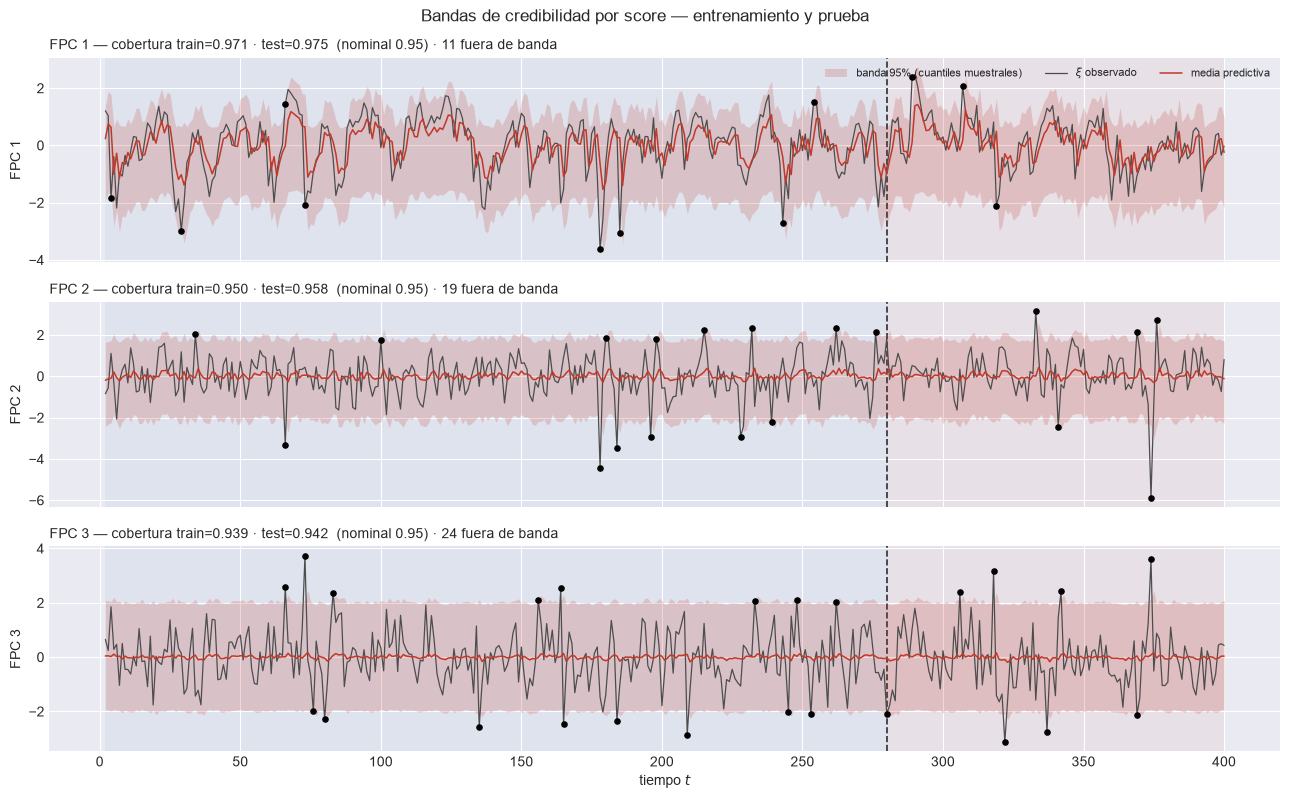

Lectura del escenario: la banda debe ser ASIMÉTRICA respecto de su centro en la
componente que hereda la asimetría de la innovación. Una banda visiblemente
simétrica en todos los orígenes es el fallo que §9 cuantifica.

razón (semiancho superior / semiancho inferior), mediana por componente:
  FPC 1: 0.5482  <- banda asimétrica
  FPC 2: 0.8633  <- banda asimétrica
  FPC 3: 1.0233  (simétrica)


In [12]:
plot_bandas_serie(
    Y_obs, Y_hat, li_s, ls_s, T0, t=t_orig,
    etiquetas=[f"FPC {i + 1}" for i in COMPONENT_IDX], nivel=NIVEL,
    title="Bandas de credibilidad por score — entrenamiento y prueba",
    save_path=str(PATHS["out_report"] / "52_bandas_scores.png"))
plt.show()
print("Lectura del escenario: la banda debe ser ASIMÉTRICA respecto de su "
      "centro en la\ncomponente que hereda la asimetría de la innovación. Una "
      "banda visiblemente\nsimétrica en todos los orígenes es el fallo que §9 "
      "cuantifica.")

# Asimetría de la banda: (ls - centro) vs (centro - li). Con una predictiva
# simétrica la razón es 1 en todos los orígenes.
razon_banda = (ls_s - Y_hat) / np.clip(Y_hat - li_s, 1e-12, None)
print("\nrazón (semiancho superior / semiancho inferior), mediana por componente:")
for k in range(n_components):
    _r = float(np.median(razon_banda[:, k]))
    marca = "  <- banda asimétrica" if abs(_r - 1.0) > 0.05 else "  (simétrica)"
    print(f"  FPC {COMPONENT_IDX[k]+1}: {_r:.4f}{marca}")

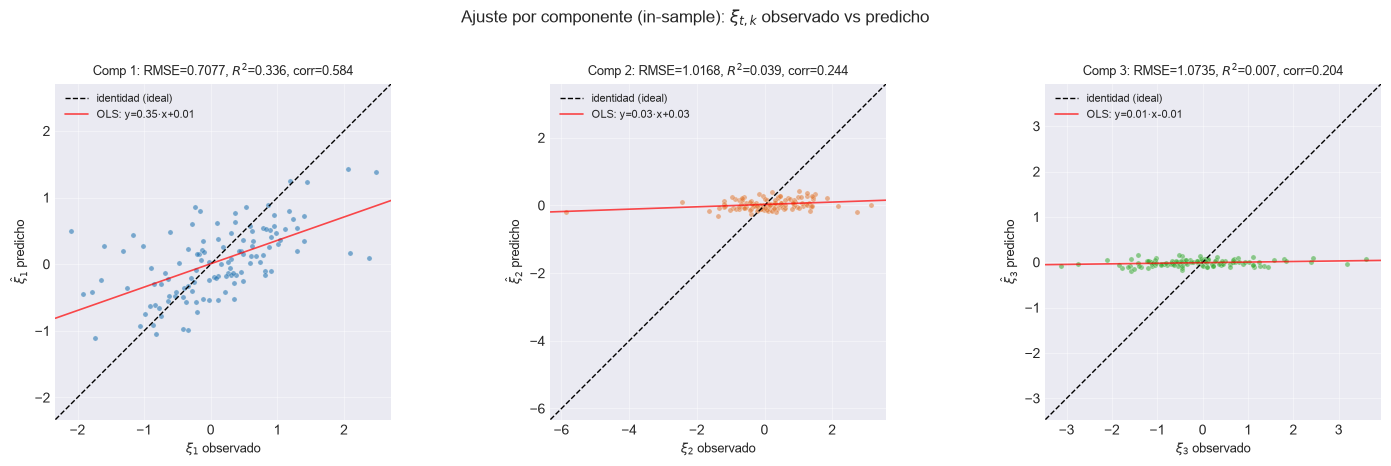

In [13]:
eval_scatter = {k: {"y_obs": Y_obs[~es_train, k], "y_hat": Y_hat[~es_train, k]}
                for k in range(n_components)}
plot_scatter_theta(eval_scatter, n_components=n_components,
                   save_path=str(PATHS["out_report"] / "53_scatter_scores_test.png"))
plt.show()

## 6. Intervalos de credibilidad sobre la curva

Extractos de la serie funcional cada `CADA` períodos, cada uno con su banda
puntual, la curva verdadera y —en gris— los datos observados, para ver de un
vistazo dónde estaba el ruido que la banda **no** tiene que cubrir.

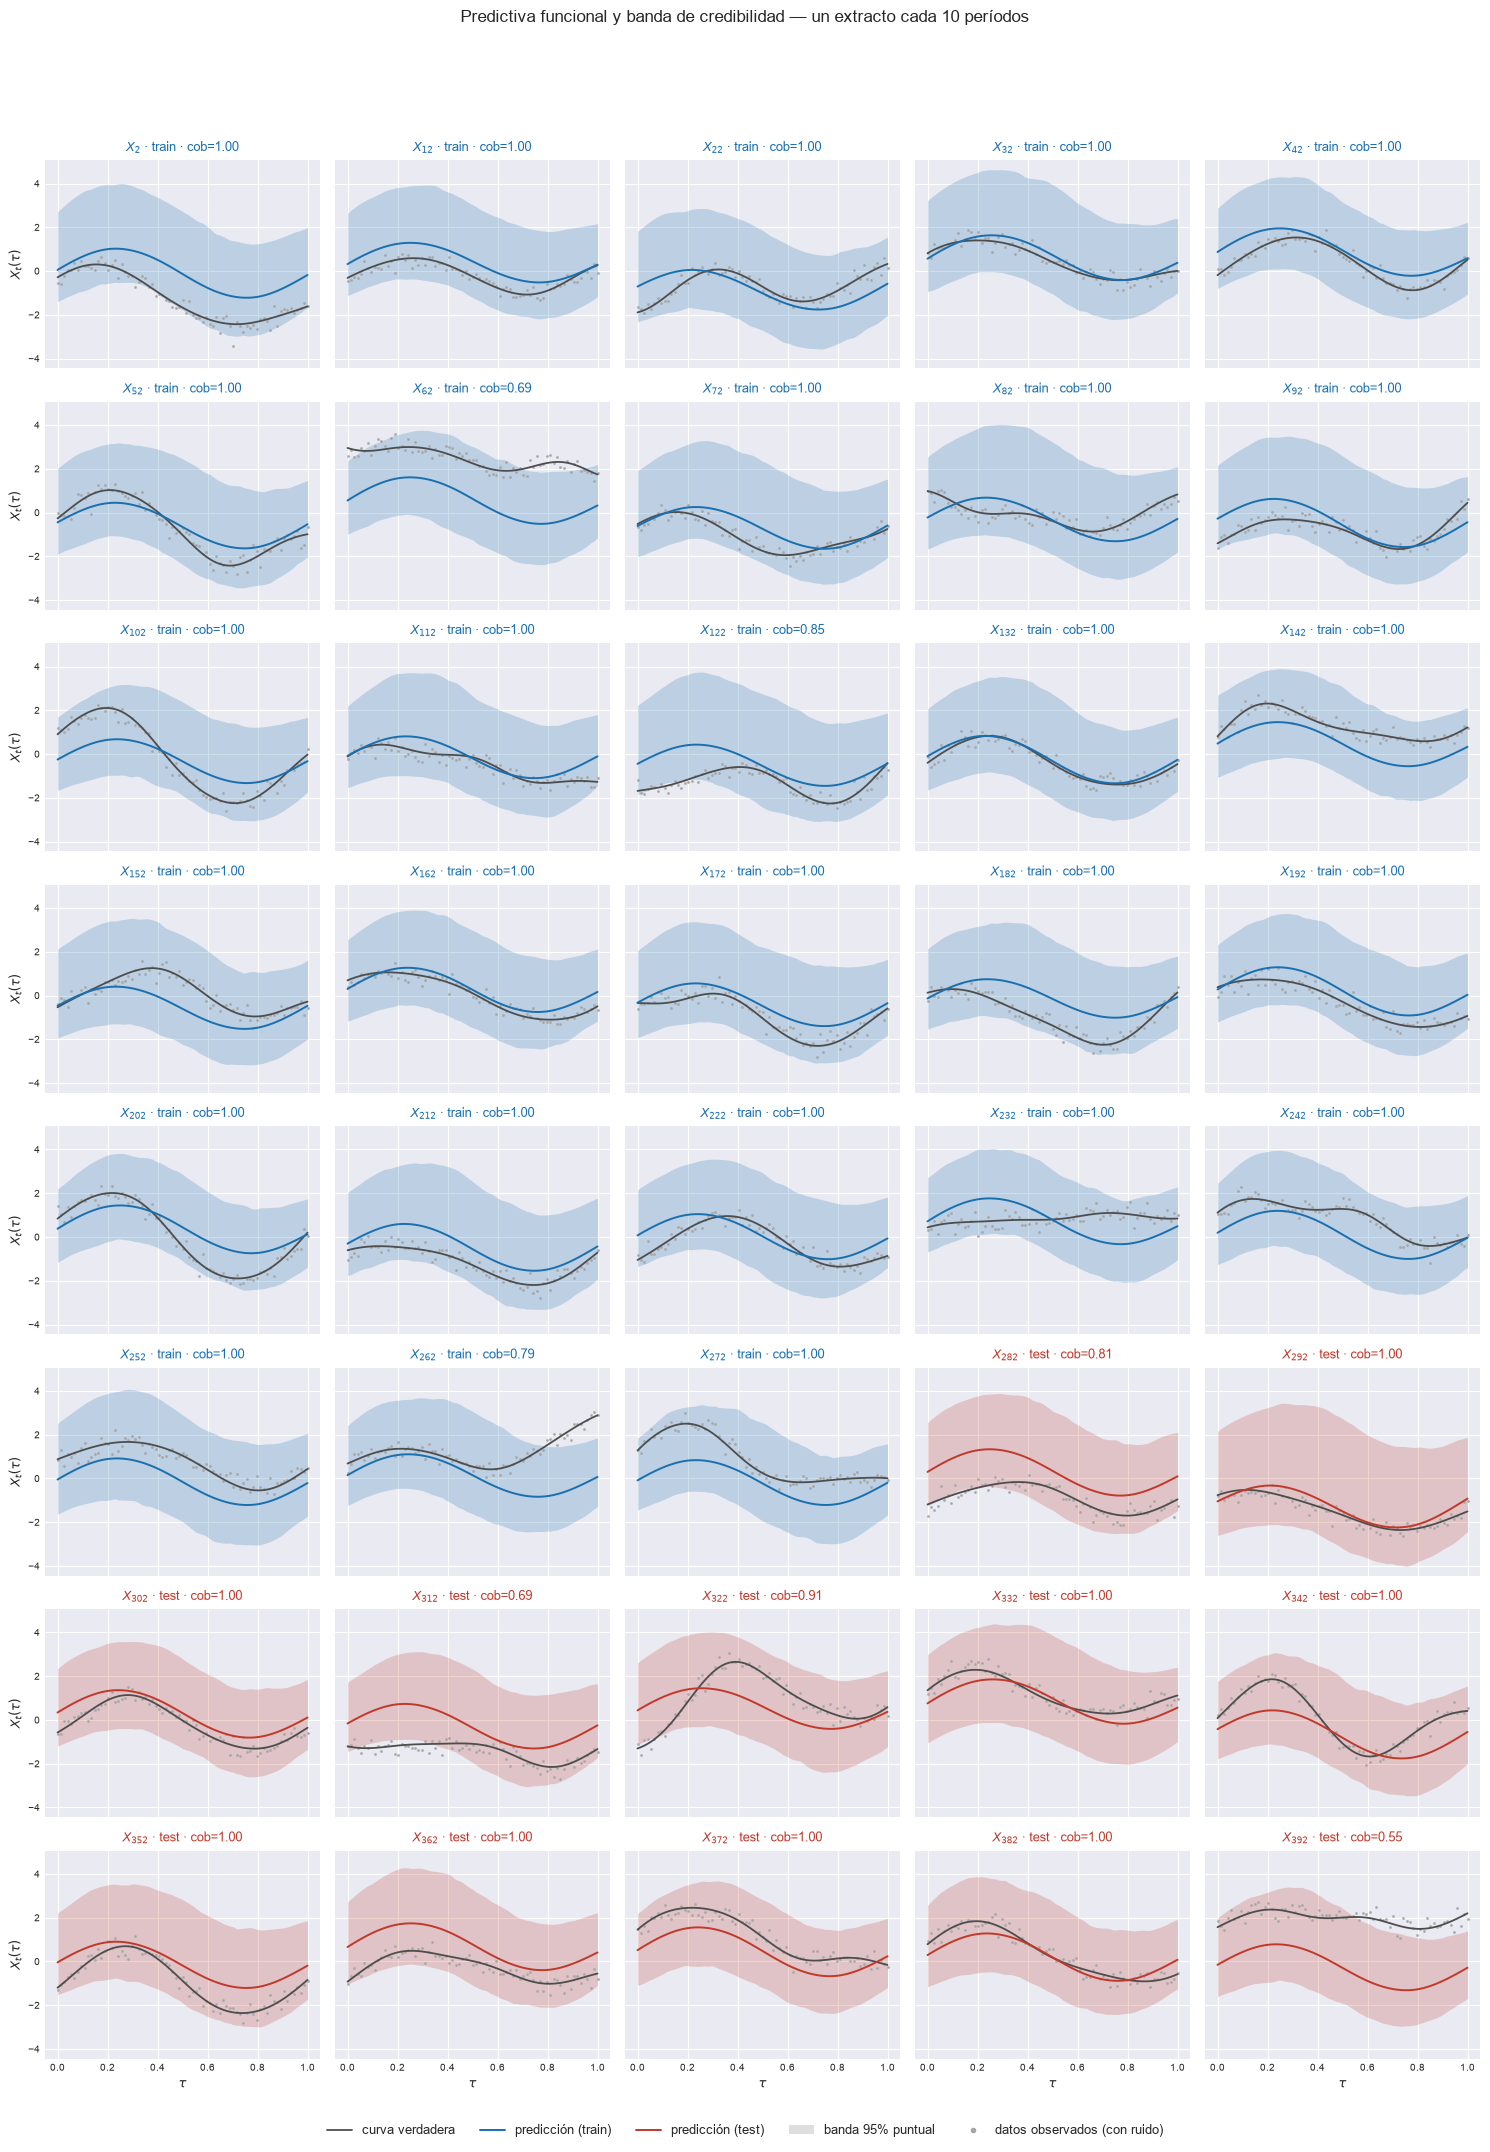

In [14]:
CADA = 10   # [CONFIG] un extracto cada CADA períodos

plot_extractos_curvas(
    X_true_ev, X_pred, li_f, ls_f, grilla, T0, t=t_orig,
    cada=CADA, n_col=5, nivel=NIVEL, X_obs=X_obs_ev,
    title="Predictiva funcional y banda de credibilidad",
    save_path=str(PATHS["out_report"] / "54_extractos_curvas.png"))
plt.show()

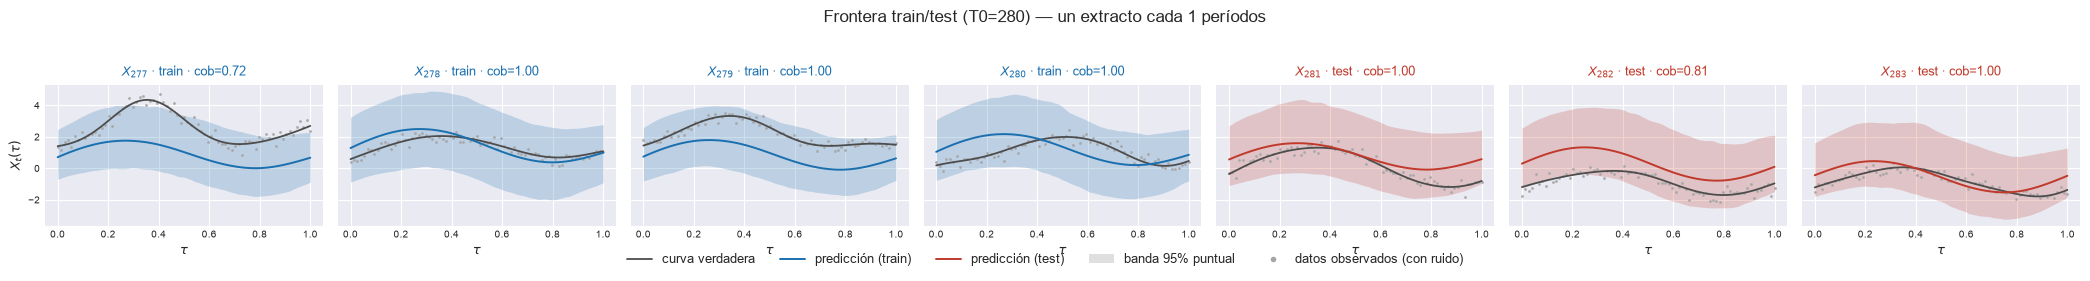

In [15]:
# Zoom sobre la frontera train/test
i_corte = int(np.searchsorted(t_orig, T0))
sel = np.arange(max(0, i_corte - 3), min(n_orig, i_corte + 4))

plot_extractos_curvas(
    X_true_ev[sel], X_pred[sel], li_f[sel], ls_f[sel], grilla, T0,
    t=t_orig[sel], cada=1, n_col=len(sel), nivel=NIVEL, X_obs=X_obs_ev[sel],
    title=f"Frontera train/test (T0={T0})",
    save_path=str(PATHS["out_report"] / "55_extractos_frontera.png"))
plt.show()

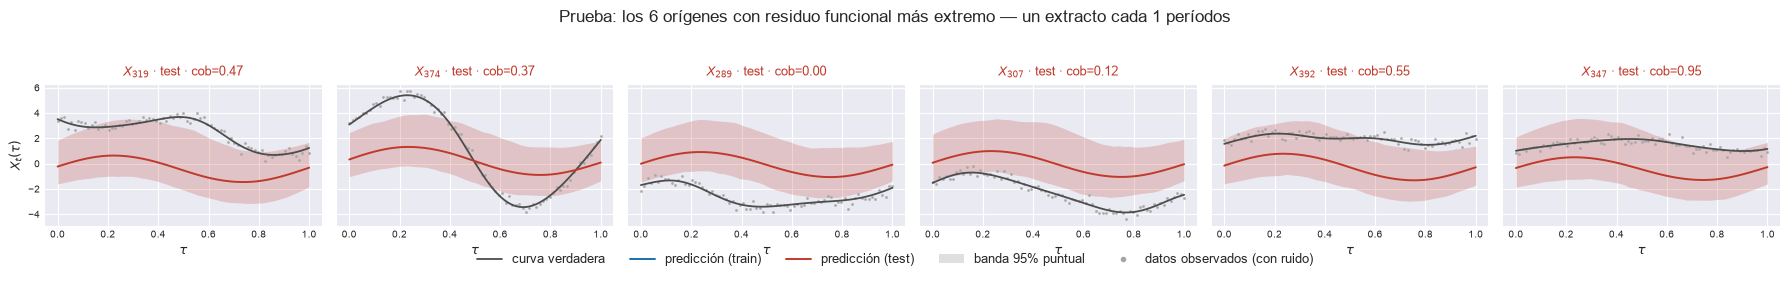

cobertura puntual: en los 6 extremos 0.4089  ·  en todo el test 0.9464
   Una caída fuerte en los extremos indica que la banda no está capturando las
   colas pesadas de la innovación: el modo de fallo propio de este escenario.

signo del residuo funcional en los 6 extremos: [1, 1, -1, -1, 1, 1]
proporción de residuos positivos en todo el test: 0.392   (0.5 bajo simetría)


In [16]:
# Extractos elegidos por MAGNITUD DEL CHOQUE y no por calendario: los orígenes
# de prueba donde el residuo funcional realizado fue más extremo. Con colas
# pesadas en la innovación, son los que un modelo gaussiano no puede cubrir, y
# donde se ve si la banda es lo bastante ancha en el lado correcto.
idx_test = np.where(~es_train)[0]
_res_norm = np.sqrt(((X_true_ev - X_pred) ** 2).mean(axis=1))
sel_ext = idx_test[np.argsort(-_res_norm[idx_test])][:6]

plot_extractos_curvas(
    X_true_ev[sel_ext], X_pred[sel_ext], li_f[sel_ext], ls_f[sel_ext],
    grilla, T0, t=t_orig[sel_ext], cada=1, n_col=len(sel_ext), nivel=NIVEL,
    X_obs=X_obs_ev[sel_ext],
    title="Prueba: los 6 orígenes con residuo funcional más extremo",
    save_path=str(PATHS["out_report"] / "56_extractos_extremos.png"))
plt.show()

_dentro_ext = ((X_true_ev[sel_ext] >= li_f[sel_ext]) &
               (X_true_ev[sel_ext] <= ls_f[sel_ext])).mean()
_dentro_all = ((X_true_ev[idx_test] >= li_f[idx_test]) &
               (X_true_ev[idx_test] <= ls_f[idx_test])).mean()
print(f"cobertura puntual: en los 6 extremos {_dentro_ext:.4f}  ·  "
      f"en todo el test {_dentro_all:.4f}")
print("   Una caída fuerte en los extremos indica que la banda no está "
      "capturando las\n   colas pesadas de la innovación: el modo de fallo "
      "propio de este escenario.")

# ¿Los extremos están sesgados hacia un lado? Con delta_skew > 0 deberían serlo.
_signo = np.sign(((X_true_ev - X_pred) * np.ones(X_true_ev.shape[1])).sum(axis=1))
print(f"\nsigno del residuo funcional en los 6 extremos: "
      f"{_signo[sel_ext].astype(int).tolist()}")
print(f"proporción de residuos positivos en todo el test: "
      f"{float((_signo[idx_test] > 0).mean()):.3f}   (0.5 bajo simetría)")

## 7. Ventana móvil

El modelo **no se reentrena**: lo que se desliza es la ventana de evaluación.
Cada punto agrega las métricas de $w$ orígenes consecutivos, todos a $h=1$ con
los rezagos reales. Se superponen varios anchos para que la conclusión no
dependa de un $w$ elegido a dedo; las ventanas que **cruzan** $T_0$ van
punteadas, porque su cifra mezcla dentro y fuera de muestra.

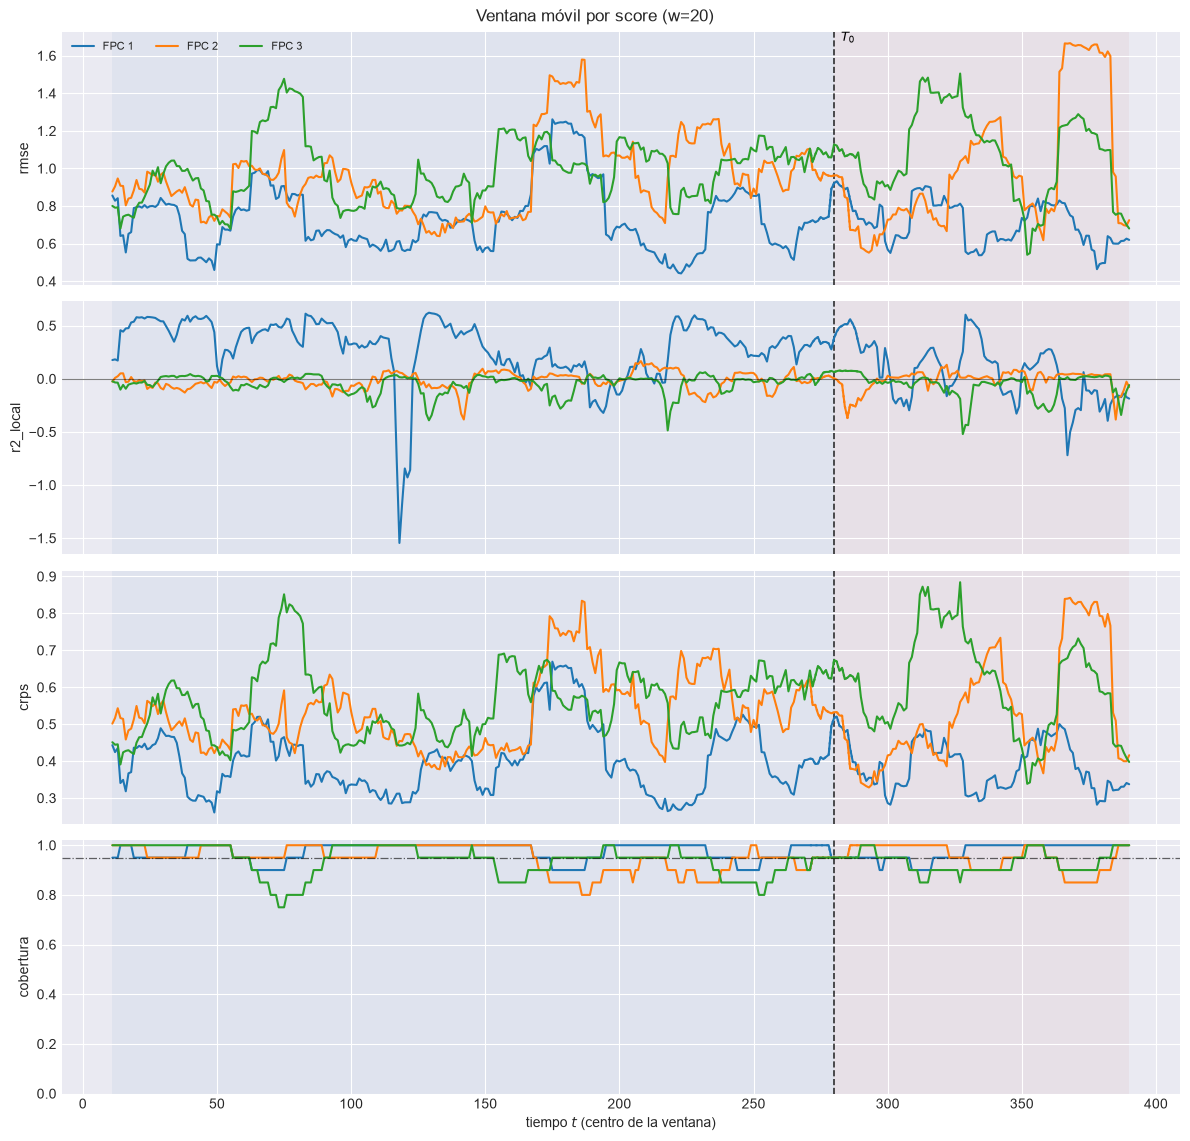

In [17]:
tablas_score = {
    w: ventana_movil_scores(
        Y_obs, Y_hat, T0_orig, w=w, muestras=SC_draws, li=li_s, ls=ls_s,
        t_offset=N_LAGS,
        etiquetas=[f"FPC {i + 1}" for i in COMPONENT_IDX])
    for w in VENTANAS_W
}
w_ref = VENTANAS_W[len(VENTANAS_W) // 2]
tablas_score[w_ref].to_csv(PATHS["out_report"] / f"57_ventana_scores_w{w_ref}.csv",
                           index=False)

plot_ventana_movil(
    tablas_score[w_ref], T0, ["rmse", "r2_local", "crps", "cobertura"],
    columna_grupo="componente",
    title=f"Ventana móvil por score (w={w_ref})",
    save_path=str(PATHS["out_report"] / "57_ventana_scores.png"))
plt.show()

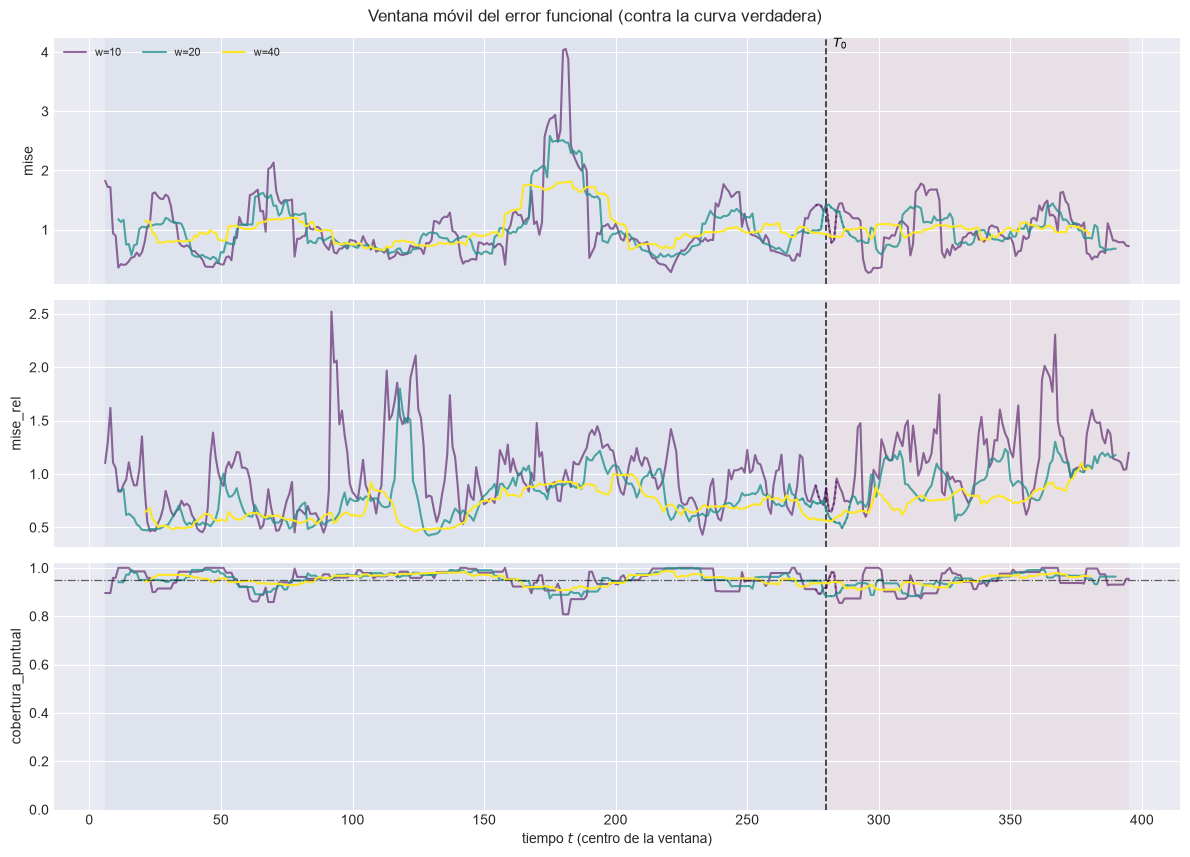

In [18]:
tablas_fun = {
    w: ventana_movil_funcional(X_true_ev, X_pred, grilla, T0_orig, w=w,
                               li=li_f, ls=ls_f, t_offset=N_LAGS)
    for w in VENTANAS_W
}
tablas_fun[w_ref].to_csv(PATHS["out_report"] / f"58_ventana_funcional_w{w_ref}.csv",
                         index=False)

plot_ventana_movil(
    tablas_fun[w_ref], T0, ["mise", "mise_rel", "cobertura_puntual"],
    tablas_por_w=tablas_fun,
    title="Ventana móvil del error funcional (contra la curva verdadera)",
    save_path=str(PATHS["out_report"] / "58_ventana_funcional.png"))
plt.show()

In [19]:
# Lectura numérica del salto en T0, excluyendo las ventanas que lo cruzan.
print(f"{'w':>4}  {'MISE train':>11}  {'MISE test':>11}  {'salto':>7}")
print(f"{'-'*4}  {'-'*11}  {'-'*11}  {'-'*7}")
for w in VENTANAS_W:
    t_ = tablas_fun[w]
    limpio = t_[~t_["cruza_T0"]]
    a = limpio.loc[limpio.bloque == "train", "mise"].mean()
    b = limpio.loc[limpio.bloque == "test",  "mise"].mean()
    print(f"{w:>4}  {a:>11.6f}  {b:>11.6f}  {b/a:>6.2f}x")

# El proceso es homogéneo: la variabilidad del MISE local debe ser ruido y no
# tendencia. Se contrasta con la magnitud del choque realizado en cada ventana.
t_ref = tablas_fun[w_ref]
if "t_fin" in t_ref.columns:
    centro = t_ref["t_fin"].to_numpy()
    choque = np.array([
        float(np.nanmean(_res_norm[max(0, int(tf) - N_LAGS - w_ref):
                                   max(1, int(tf) - N_LAGS)]))
        for tf in centro])
    _c = np.corrcoef(t_ref["mise"].to_numpy(), choque)[0, 1]
    print(f"\ncorr(MISE local, magnitud media del choque en la ventana) = {_c:+.3f}")
    print("   Alta y positiva: la variación del error local sigue a la magnitud "
          "de la\n   innovación realizada, que es lo esperable en un proceso "
          "homogéneo con colas\n   pesadas. No es degradación del modelo.")

   w   MISE train    MISE test    salto
----  -----------  -----------  -------
  10     1.011742     0.979681    0.97x
  20     1.016451     0.977094    0.96x
  40     1.024660     1.009633    0.99x

corr(MISE local, magnitud media del choque en la ventana) = +0.944
   Alta y positiva: la variación del error local sigue a la magnitud de la
   innovación realizada, que es lo esperable en un proceso homogéneo con colas
   pesadas. No es degradación del modelo.


## 8. Calibración marginal

Bajo calibración perfecta el PIT es uniforme. La **forma** dice qué falla: una
U indica bandas demasiado angostas, una campana demasiado anchas, y una
pendiente un sesgo del centro. Contrastar train contra test separa el desajuste
del modelo de la pérdida de calibración fuera de muestra.

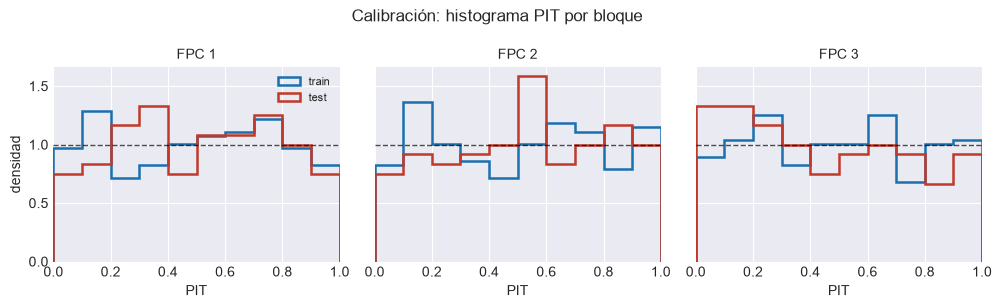

,ks_train,forma_train,ks_test,forma_test,media_pit_train,media_pit_test,asim_pit_test
FPC,,,,,,,
FPC 1,0.0370,aproximadamente uniforme,0.0546,aproximadamente uniforme,0.5008,0.5063,0.0473
FPC 2,0.0438,aproximadamente uniforme,0.0657,aproximadamente uniforme,0.5010,0.5314,0.2426
FPC 3,0.0360,aproximadamente uniforme,0.1040,aproximadamente uniforme,0.4982,0.4531,-0.2374



desviación de la media del PIT respecto de 0.5 (test):
  FPC 1      +0.0063
  FPC 2      +0.0314  <- inclinación sistemática
  FPC 3      -0.0469  <- inclinación sistemática

signo de la asimetría del generador: positiva (+0.901)
   Si las desviaciones del PIT comparten signo y siguen a la asimetría del
   generador, la predictiva NO está recogiendo la forma. Si son pequeñas y de
   signo variable, sí lo está.


In [20]:
pit_tr = {f"FPC {COMPONENT_IDX[k]+1}": pit_muestral(Y_obs[es_train, k],
                                                    SC_draws[:, es_train, k])
          for k in range(n_components)}
pit_te = {f"FPC {COMPONENT_IDX[k]+1}": pit_muestral(Y_obs[~es_train, k],
                                                    SC_draws[:, ~es_train, k])
          for k in range(n_components)}

plot_calibracion_pit(pit_tr, pit_te,
                     save_path=str(PATHS["out_report"] / "60_pit.png"))
plt.show()

filas_pit = []
for nombre in pit_tr:
    d_tr, d_te = diagnostico_pit(pit_tr[nombre]), diagnostico_pit(pit_te[nombre])
    filas_pit.append({
        "FPC": nombre,
        "ks_train": float(d_tr["ks"]), "forma_train": d_tr["forma"],
        "ks_test":  float(d_te["ks"]), "forma_test":  d_te["forma"],
        "media_pit_train": float(np.mean(pit_tr[nombre])),
        "media_pit_test":  float(np.mean(pit_te[nombre])),
        "asim_pit_test":   float(np.mean((pit_te[nombre] - 0.5) ** 3) /
                                 max(np.mean((pit_te[nombre] - 0.5) ** 2) ** 1.5, 1e-12)),
    })
pit_df = pd.DataFrame(filas_pit).set_index("FPC")
pit_df.to_csv(PATHS["out_report"] / "60_pit_diagnostico.csv")

display(pit_df.style.format({c: "{:.4f}" for c in pit_df.columns
                             if pit_df[c].dtype.kind == "f"})
        .set_caption("PIT por bloque · la media se desvía de 0.5 cuando la "
                     "predictiva pone masa del lado equivocado"))

_desv = (pit_df["media_pit_test"] - 0.5)
print(f"\ndesviación de la media del PIT respecto de 0.5 (test):")
for nombre, v in _desv.items():
    marca = ("  <- inclinación sistemática" if abs(v) > 0.03 else "")
    print(f"  {nombre:<10} {v:+.4f}{marca}")
print(f"\nsigno de la asimetría del generador: "
      f"{'positiva' if asim_residuo_true > 0 else 'negativa'} "
      f"({asim_residuo_true:+.3f})")
print("   Si las desviaciones del PIT comparten signo y siguen a la asimetría "
      "del\n   generador, la predictiva NO está recogiendo la forma. Si son "
      "pequeñas y de\n   signo variable, sí lo está.")

## 9. ¿Recupera la predictiva la asimetría de la condicional?

**El resultado central de esta corrida.** Ocupa el lugar que en las corridas 12
y 13 ocupaba la calibración condicional al estado verdadero, y no lo hace por
sustitución sino porque aquí no hay estado: lo que el generador introduce no es
un régimen sino una **forma**.

Bajo este generador la ley de $X_t\mid X_{t-1}$ es asimétrica y de colas pesadas
alrededor de una media lineal correctamente especificada. La respuesta correcta
es una predictiva **asimétrica**; la respuesta de cualquier método con
verosimilitud gaussiana es una predictiva simétrica con la varianza inflada para
cubrir la cola larga —lo que también ensancha la cola corta, donde no hace
falta—.

Se comparan tres cantidades por componente FPCA:

1. **`asim_draws`**: la asimetría muestral de los draws predictivos, promediada
   sobre los orígenes de prueba. Es lo que el modelo produce.
2. **`asim_residuo`**: la asimetría de los residuos realizados
   $y_t-\hat y_t$ en el mismo bloque. Es lo que hay que reproducir.
3. **`asim_score_train`**: la asimetría marginal del score en entrenamiento, tal
   como la registró `14_01`. Es la referencia del generador, independiente del
   ajuste.

Las tres se comparan entre sí y no contra un umbral: el valor absoluto depende
de `delta_skew`, de `hs_norm` y de cuánta asimetría sobrevivió a la proyección
FPCA, de modo que **la comparación interna es lo informativo**. Un modelo que
sólo estimara la media produciría `asim_draws` ≈ 0 con `asim_residuo` claramente
distinto de cero: ésa es la separación que el escenario existe para medir.

Se añade la **curtosis**, por la misma razón y con la misma lectura: la mezcla
de escala produce colas más pesadas que la gaussiana, y una predictiva que las
reproduzca debe tener curtosis por encima de 3.

In [21]:
def _asim_curt(Z, eje=0):
    """Asimetría y curtosis (no exceso), estandarizadas a lo largo de `eje`."""
    Zc = Z - Z.mean(axis=eje, keepdims=True)
    m2 = np.mean(Zc ** 2, axis=eje)
    sd = np.sqrt(np.where(m2 > 0, m2, np.nan))
    return (np.mean(Zc ** 3, axis=eje) / sd ** 3,
            np.mean(Zc ** 4, axis=eje) / sd ** 4)

m_te = ~es_train
filas_forma = []
for k in range(n_components):
    # (a) forma de la predictiva: asimetría de los draws en cada origen de
    #     prueba, promediada sobre orígenes. Se calcula POR ORIGEN porque es la
    #     condicional lo que debe ser asimétrica, no la mezcla de condicionales.
    a_por_origen, c_por_origen = _asim_curt(SC_draws[:, m_te, k], eje=0)
    # (b) forma de los residuos realizados en el mismo bloque
    resid = Y_obs[m_te, k] - Y_hat[m_te, k]
    a_res, c_res = _asim_curt(resid[:, None], eje=0)
    filas_forma.append({
        "FPC": f"FPC {COMPONENT_IDX[k] + 1}",
        "asim_draws":       float(np.nanmean(a_por_origen)),
        "asim_draws_sd":    float(np.nanstd(a_por_origen)),
        "asim_residuo":     float(a_res[0]),
        "asim_score_train": (float(ASIM_SCORES_TRUE[k])
                             if k < ASIM_SCORES_TRUE.size else np.nan),
        "curt_draws":       float(np.nanmean(c_por_origen)),
        "curt_residuo":     float(c_res[0]),
        "n_test":           int(m_te.sum()),
    })

forma_df = pd.DataFrame(filas_forma).set_index("FPC")
forma_df.to_csv(PATHS["out_report"] / "63_forma_predictiva.csv")

display(forma_df.style
    .format({c: "{:+.4f}" for c in ["asim_draws", "asim_residuo",
                                    "asim_score_train"]})
    .format({c: "{:.4f}" for c in ["asim_draws_sd", "curt_draws", "curt_residuo"]})
    .background_gradient(subset=["asim_draws"], cmap="PuOr", vmin=-1, vmax=1)
    .set_caption("Forma de la predictiva contra la forma verdadera · "
                 "bloque de prueba"))

print("curtosis de referencia: gaussiana = 3.0000   ·   "
      f"innovación del generador = {curt_residuo_true:.4f}")

# Componente donde la asimetría verdadera es mayor: es la que decide.
_k_dec = int(np.nanargmax(np.abs(forma_df["asim_residuo"].to_numpy())))
_fila  = forma_df.iloc[_k_dec]
print(f"\ncomponente decisiva (mayor asimetría en el residuo): "
      f"{forma_df.index[_k_dec]}")
print(f"  asimetría del residuo realizado : {_fila['asim_residuo']:+.4f}")
print(f"  asimetría de la predictiva      : {_fila['asim_draws']:+.4f}"
      f"   (sd entre orígenes {_fila['asim_draws_sd']:.4f})")
_recup = (float(_fila["asim_draws"]) / float(_fila["asim_residuo"])
          if abs(float(_fila["asim_residuo"])) > 1e-6 else np.nan)
print(f"  fracción recuperada             : {_recup:.2f}")

_mismo_signo = np.sign(_fila["asim_draws"]) == np.sign(_fila["asim_residuo"])
print("\nVEREDICTO de §9: "
      + ("la predictiva reproduce la asimetría de la condicional"
         if (_mismo_signo and abs(_recup) > 0.3) else
         "la predictiva NO recoge la asimetría: el modelo responde con una "
         "densidad\n  esencialmente simétrica a datos que no lo son. Es el "
         "fallo que este\n  escenario existe para detectar."))

,asim_draws,asim_draws_sd,asim_residuo,asim_score_train,curt_draws,curt_residuo,n_test
FPC,,,,,,,
FPC 1,-1.194549,0.3884,-0.642011,-0.739989,6.5148,4.9731,120
FPC 2,-0.439939,0.0642,-1.259840,-0.612960,4.9019,11.3202,120
FPC 3,0.049898,0.0221,0.491576,0.100749,3.7412,4.1651,120


curtosis de referencia: gaussiana = 3.0000   ·   innovación del generador = 5.2481

componente decisiva (mayor asimetría en el residuo): FPC 2
  asimetría del residuo realizado : -1.2598
  asimetría de la predictiva      : -0.4399   (sd entre orígenes 0.0642)
  fracción recuperada             : 0.35

VEREDICTO de §9: la predictiva reproduce la asimetría de la condicional


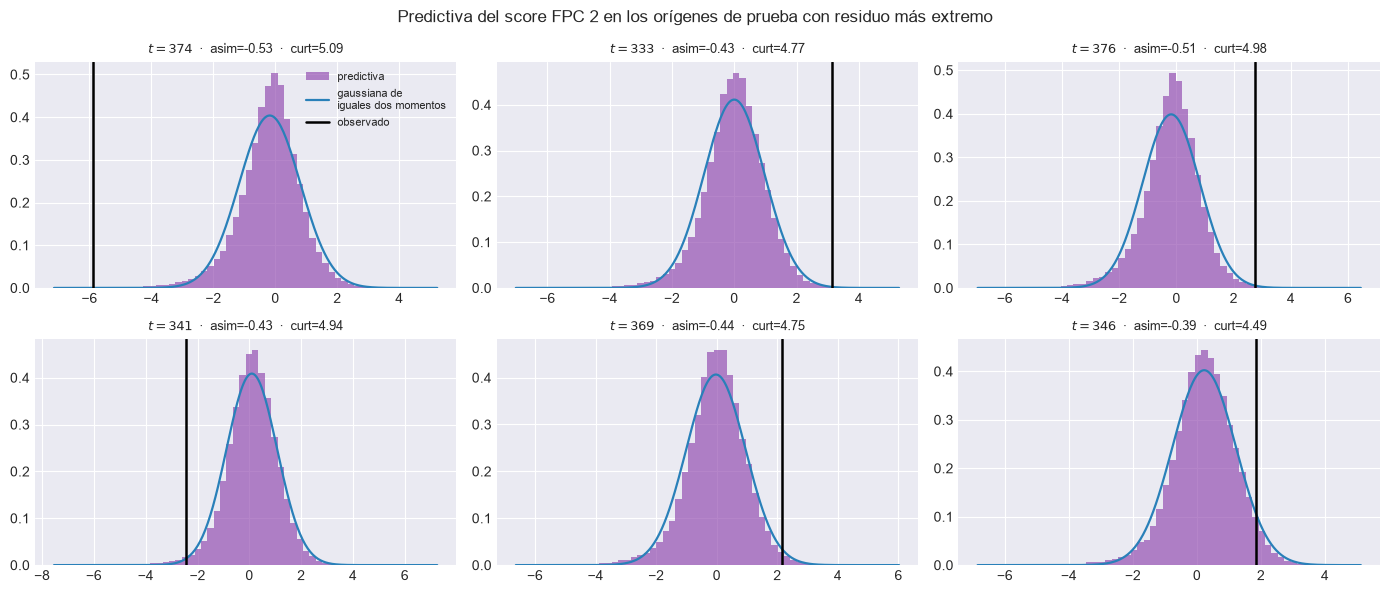

Lo que hay que mirar: si el histograma se separa visiblemente de la curva azul —cola
larga de un lado, hombro corto del otro— la mezcla está haciendo su trabajo. Si
coinciden, la posterior colapsó a una componente gaussiana y §9 lo confirma con
números.


In [22]:
# Densidades predictivas en los 6 orígenes de prueba con residuo más extremo,
# en la componente decisiva. Sobre cada una, la gaussiana de los MISMOS dos
# momentos: la brecha entre ambas es exactamente lo que un método con
# verosimilitud gaussiana no puede representar.
k_sel = _k_dec
sel6  = idx_test[np.argsort(-np.abs(Y_obs[idx_test, k_sel] - Y_hat[idx_test, k_sel]))][:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=False)
for ax, i in zip(axes.ravel(), sel6):
    z = SC_draws[:, i, k_sel]
    ax.hist(z, bins=60, density=True, color="#8e44ad", alpha=0.65,
            label="predictiva" if ax is axes[0, 0] else None)
    _x = np.linspace(z.min(), z.max(), 300)
    ax.plot(_x, _norm.pdf(_x, z.mean(), z.std()), color="#2980b9", lw=1.6,
            label="gaussiana de\niguales dos momentos" if ax is axes[0, 0] else None)
    ax.axvline(Y_obs[i, k_sel], color="k", lw=1.8,
               label="observado" if ax is axes[0, 0] else None)
    _a = _asim_curt(z[:, None])
    ax.set_title(f"$t={t_orig[i]}$  ·  asim={float(_a[0][0]):+.2f}  ·  "
                 f"curt={float(_a[1][0]):.2f}", fontsize=9)
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"Predictiva del score {forma_df.index[k_sel]} en los orígenes de "
             f"prueba con residuo más extremo", fontsize=12)
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "64_predictiva_asimetria.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Lo que hay que mirar: si el histograma se separa visiblemente de la "
      "curva azul —cola\nlarga de un lado, hombro corto del otro— la mezcla "
      "está haciendo su trabajo. Si\ncoinciden, la posterior colapsó a una "
      "componente gaussiana y §9 lo confirma con\nnúmeros.")

In [23]:
# Cuantificación agregada: ¿cubre la banda de forma DESIGUAL a cada lado?
# Con una innovación de asimetría positiva, los excesos por arriba deberían ser
# más frecuentes que los excesos por abajo si la predictiva es simétrica.
print("Excesos fuera de la banda al 95% por LADO, bloque de prueba:")
for k in range(n_components):
    y = Y_obs[m_te, k]
    ab = float((y < li_s[m_te, k]).mean())
    ar = float((y > ls_s[m_te, k]).mean())
    print(f"  FPC {COMPONENT_IDX[k]+1}: por debajo {ab:.4f}   por encima {ar:.4f}"
          f"   (nominal {(1-NIVEL)/2:.4f} cada uno)"
          + ("   <- desequilibrio" if abs(ab - ar) > 0.02 else ""))
print("\nUn desequilibrio sistemático es la firma de una banda simétrica sobre "
      "una\ncondicional que no lo es: sobra cobertura del lado corto y falta "
      "del largo.")

Excesos fuera de la banda al 95% por LADO, bloque de prueba:
  FPC 1: por debajo 0.0083   por encima 0.0167   (nominal 0.0250 cada uno)
  FPC 2: por debajo 0.0167   por encima 0.0250   (nominal 0.0250 cada uno)
  FPC 3: por debajo 0.0250   por encima 0.0333   (nominal 0.0250 cada uno)

Un desequilibrio sistemático es la firma de una banda simétrica sobre una
condicional que no lo es: sobra cobertura del lado corto y falta del largo.


## 10. Comparación con las líneas base

In [24]:
_bl = PATHS["out_report"] / "30_baselines_test.csv"
rmse_psbp = met_df.loc["test", "RMSE"].mean()
print(f"RMSE promedio en scores — PSBP-FD (test): {rmse_psbp:.4f}\n")

if _bl.exists():
    baselines_df = pd.read_csv(_bl, index_col=0)
    display(baselines_df.style.format("{:.4f}", na_rep="—")
            .set_caption("Líneas base sobre el bloque de prueba (h=1)"))
    if "RMSE_scores_prom" in baselines_df.columns:
        for modelo, fila in baselines_df.iterrows():
            marca = "PSBP mejor" if rmse_psbp < fila["RMSE_scores_prom"] else "baseline mejor"
            print(f"  vs {modelo:24s} RMSE={fila['RMSE_scores_prom']:.4f}  → {marca}")
else:
    print("[AVISO] falta 30_baselines_test.csv — ejecuta 14_01 §6.")

print("\nLectura para el Escenario 4: ganar en RMSE es exigible —hay dependencia "
      "genuina en\nla media, la misma del Algoritmo 1— pero NO es el resultado "
      "de la corrida. La\nmedia condicional está correctamente especificada "
      "para todos los competidores; lo\nque los separa es la forma de la "
      "predictiva, y eso lo miden CRPS, el puntaje de\nenergía y §9.")
print("\nNota: sólo hay dos líneas base (media incondicional y persistencia). "
      "FAR(1),\nVAR sobre scores y ARIMA por score siguen pendientes en "
      "fit/baselines.py.")

RMSE promedio en scores — PSBP-FD (test): 0.9326



,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,120.0000,0.8740,1.0464,1.0864,1.0023,-0.0157,1.3178,1.1480
persistencia_lag1,120.0000,0.7908,1.2635,1.3847,1.1463,-0.3214,1.2576,1.1214


  vs media_incondicional      RMSE=1.0023  → PSBP mejor
  vs persistencia_lag1        RMSE=1.1463  → PSBP mejor

Lectura para el Escenario 4: ganar en RMSE es exigible —hay dependencia genuina en
la media, la misma del Algoritmo 1— pero NO es el resultado de la corrida. La
media condicional está correctamente especificada para todos los competidores; lo
que los separa es la forma de la predictiva, y eso lo miden CRPS, el puntaje de
energía y §9.

Nota: sólo hay dos líneas base (media incondicional y persistencia). FAR(1),
VAR sobre scores y ARIMA por score siguen pendientes en fit/baselines.py.


### 10.1 Bloque de cifras para el contraste con la corrida 11

**Este es el cierre de la corrida.** El Algoritmo 4 no se lee solo: sus cifras
sólo significan algo puestas al lado de las del Algoritmo 1, que comparte
dinámica, base, `M`, rezagos, priors y `mcmc_config`, y difiere únicamente en la
ley de la innovación.

La expectativa del diseño, explícita para que el contraste sea falsable:

| Cantidad | Esperado frente a la corrida 11 |
|---|---|
| RMSE, $R^2$ | **coinciden** — la media condicional es la misma |
| CRPS, energía | **peores en 14**, pero menos de lo que empeoraría un método gaussiano |
| PIT (forma, media) | **inclinado en 14**, uniforme en 11 |
| asimetría de la predictiva | **distinta de cero en 14**, nula en 11 |
| ocupación de la mezcla (`14_03 §4`) | **mayor en 14** |
| PIP (`14_03 §6`) | **coinciden** — misma estructura de dependencia |

In [25]:
# ── Resumen ejecutable del experimento ───────────────────────────────────────
resumen = {
    "experiment_id": EXPERIMENT_ID,
    "escenario_id": int(ESCENARIO_ID),
    "objetivo_evaluacion": OBJETIVO,
    "modo_residuo": MODO_RESIDUO,
    "nivel": NIVEL,
    "S_scores": int(S_total), "S_funcional": int(X_draws.shape[0]),
    # Puntual: debe COINCIDIR con la corrida 11
    "rmse_scores_train": float(met_df.loc["train", "RMSE"].mean()),
    "rmse_scores_test":  float(met_df.loc["test", "RMSE"].mean()),
    "r2_scores_test":    float(met_df.loc["test", "R2"].mean()),
    # Distribucional: aquí debe verse la diferencia
    "crps_scores_test":  float(met_df.loc["test", "CRPS"].mean()),
    "mise_train": float(fun_df.loc["train", "MISE"]),
    "mise_test":  float(fun_df.loc["test", "MISE"]),
    "mise_truncamiento_test": float(fun_df.loc["test", "MISE_truncamiento"]),
    "energy_test": float(fun_df.loc["test", "energy"]),
    "cobertura_puntual_test": float(fun_df.loc["test", f"Cob{int(NIVEL*100)}_puntual"]),
    # Forma (§9) — el resultado central
    "fpc_decisiva":            int(COMPONENT_IDX[_k_dec] + 1),
    "asim_predictiva":         float(forma_df["asim_draws"].iloc[_k_dec]),
    "asim_residuo_realizado":  float(forma_df["asim_residuo"].iloc[_k_dec]),
    "asim_score_generador":    float(forma_df["asim_score_train"].iloc[_k_dec]),
    "fraccion_asimetria_recuperada": float(_recup),
    "curt_predictiva":         float(forma_df["curt_draws"].iloc[_k_dec]),
    "curt_residuo_realizado":  float(forma_df["curt_residuo"].iloc[_k_dec]),
    # Calibración marginal
    "pit_media_test":          float(pit_df["media_pit_test"].mean()),
    "pit_ks_test_max":         float(pit_df["ks_test"].max()),
    # Referencia del generador
    "asim_innovacion_generador": float(asim_residuo_true),
    "curt_innovacion_generador": float(curt_residuo_true),
    "comparacion_de_referencia": REF_CFG.get("experiment_id", "escenario_1_r01"),
}
pd.Series(resumen).to_csv(PATHS["out_report"] / "65_resumen.csv", header=False)
for k, v in resumen.items():
    print(f"  {k:32s}: {v}")
print(f"\nFiguras y tablas en {PATHS['out_report']}")
print(f"\nPara cerrar la corrida, abrir el 65_resumen.csv de "
      f"{REF_CFG.get('experiment_id', 'escenario_1_r01')} y comparar fila a "
      f"fila\nsegún la tabla de §10.1.")

  experiment_id                   : escenario_4_r01
  escenario_id                    : 4
  objetivo_evaluacion             : curva_verdadera
  modo_residuo                    : ninguno
  nivel                           : 0.95
  S_scores                        : 45000
  S_funcional                     : 500
  rmse_scores_train               : 0.9131053268747048
  rmse_scores_test                : 0.9326330610473382
  r2_scores_test                  : 0.12757599097650738
  crps_scores_test                : 0.4972076241514151
  mise_train                      : 1.0434844540551103
  mise_test                       : 0.9544392694846521
  mise_truncamiento_test          : 0.04386328516985504
  energy_test                     : 5.145817341635933
  cobertura_puntual_test          : 0.9464444444444444
  fpc_decisiva                    : 2
  asim_predictiva                 : -0.43993934988975525
  asim_residuo_realizado          : -1.2598395853060855
  asim_score_generador            : -0.61296